# Modelling

Two classifiers (Logistic Regression and LightGBM) trained on the processed data from `preprocessing.ipynb`. Both handle the class imbalance (~12% positive) via built-in class weighting. We train each model first on the original features, then on engineered features to see if it makes a difference.

## Workflow

1. Import libraries
2. Load data
3. Part A: train on original features
4. Part B: feature engineering + retrain
5. Compare all models
6. Evaluation plots
7. Test set predictions + submission
8. Conclusion

## Step 1: Import required libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

## Step 2: Load the processed data


In [2]:
df_train = pd.read_parquet('data/processed/train_final.parquet')
df_test = pd.read_parquet('data/processed/test_final.parquet')

## Step 3 (Part A): Models on original features

Train both models on all the original columns with no modifications. 80/20 stratified split.

In [3]:
# Part A: select features, split, train both models
original_features = ['Age', 'Gender', 'Driving_License', 'Region_Code', 'Previously_Insured',
                     'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium', 'Policy_Sales_Channel', 'Vintage']

X_orig = df_train[original_features]
y = df_train['Response']
X_test_orig = df_test[original_features]

X_train_o, X_val_o, y_train, y_val = train_test_split(
    X_orig, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train_o.shape}  |  Val: {X_val_o.shape}')

# Logistic Regression
scaler_orig = StandardScaler()
X_train_o_sc = scaler_orig.fit_transform(X_train_o)
X_val_o_sc = scaler_orig.transform(X_val_o)

lr_orig = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_orig.fit(X_train_o_sc, y_train)
lr_orig_preds = lr_orig.predict_proba(X_val_o_sc)[:, 1]
lr_orig_auc = roc_auc_score(y_val, lr_orig_preds)
print(f'LR  (original)  ROC-AUC: {lr_orig_auc:.4f}')

# LightGBM
lgb_orig = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, is_unbalance=True,
                               random_state=42, n_jobs=-1, importance_type='gain')
lgb_orig.fit(X_train_o, y_train, eval_set=[(X_val_o, y_val)])
lgb_orig_preds = lgb_orig.predict_proba(X_val_o)[:, 1]
lgb_orig_auc = roc_auc_score(y_val, lgb_orig_preds)
print(f'LGB (original)  ROC-AUC: {lgb_orig_auc:.4f}')

Train: (9203838, 10)  |  Val: (2300960, 10)
LR  (original)  ROC-AUC: 0.8365
[LightGBM] [Info] Number of positive: 1132047, number of negative: 8071791
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087700 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 736
[LightGBM] [Info] Number of data points in the train set: 9203838, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.122997 -> initscore=-1.964348
[LightGBM] [Info] Start training from score -1.964348
LGB (original)  ROC-AUC: 0.8784


## Step 4 (Part B): Models on engineered features

Three changes based on the EDA findings:

1. **Drop `Vehicle_Damage`**: nearly collinear with `Previously_Insured` (r ≈ −0.84), so it's basically redundant info
2. **Frequency-encode `Region_Code` and `Policy_Sales_Channel`**: these are arbitrary integer labels, not real numbers. Replace each code with how common it is (e.g. 15% of customers → 0.15). Frequencies computed only on the train split to avoid leakage
3. **`Age × Vehicle_Age` interaction**: the EDA showed the relationship between these two is driven by a sharp break in the 20–29 group, not a smooth gradient. Multiplying them gives the model that combined signal directly

In [4]:
def engineer_features(df, region_freq=None, channel_freq=None):
    """Apply the three FE transformations. Returns (df, region_freq, channel_freq)."""
    df = df.copy()

    df = df.drop(columns=['Vehicle_Damage'])

    # frequency encoding, compute from df if no precomputed map is passed
    if region_freq is None:
        region_freq = df['Region_Code'].value_counts(normalize=True)
    if channel_freq is None:
        channel_freq = df['Policy_Sales_Channel'].value_counts(normalize=True)

    df['Region_Freq']  = df['Region_Code'].map(region_freq).fillna(0).astype('float32')
    df['Channel_Freq'] = df['Policy_Sales_Channel'].map(channel_freq).fillna(0).astype('float32')
    df = df.drop(columns=['Region_Code', 'Policy_Sales_Channel'])

    # interaction
    df['Age_x_VehicleAge'] = (df['Age'] * df['Vehicle_Age']).astype('int16')

    return df, region_freq, channel_freq

In [5]:
# Part B: split first, THEN engineer (avoids leakage in frequency encoding)
eng_features = ['Age', 'Gender', 'Driving_License', 'Previously_Insured',
                'Vehicle_Age', 'Annual_Premium', 'Vintage',
                'Region_Freq', 'Channel_Freq', 'Age_x_VehicleAge']

# same random_state → same row partition as Part A
X_raw_train, X_raw_val, y_train_e, y_val_e = train_test_split(
    df_train, y, test_size=0.2, random_state=42, stratify=y)

# engineer on train split → get freq maps, then apply to val and test
X_train_fe, region_freq, channel_freq = engineer_features(X_raw_train)
X_val_fe, _, _ = engineer_features(X_raw_val, region_freq, channel_freq)
X_test_fe, _, _ = engineer_features(df_test, region_freq, channel_freq)

X_train_e = X_train_fe[eng_features]
X_val_e   = X_val_fe[eng_features]
X_test_eng = X_test_fe[eng_features]
print(f'Train: {X_train_e.shape}  |  Val: {X_val_e.shape}')

# Logistic Regression (engineered)
scaler_eng = StandardScaler()
X_train_e_sc = scaler_eng.fit_transform(X_train_e)
X_val_e_sc = scaler_eng.transform(X_val_e)

lr_eng = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_eng.fit(X_train_e_sc, y_train_e)
lr_eng_preds = lr_eng.predict_proba(X_val_e_sc)[:, 1]
lr_eng_auc = roc_auc_score(y_val_e, lr_eng_preds)
print(f'LR  (engineered) ROC-AUC: {lr_eng_auc:.4f}')

# LightGBM (engineered)
lgb_eng = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, is_unbalance=True,
                              random_state=42, n_jobs=-1, importance_type='gain')
lgb_eng.fit(X_train_e, y_train_e, eval_set=[(X_val_e, y_val_e)])
lgb_eng_preds = lgb_eng.predict_proba(X_val_e)[:, 1]
lgb_eng_auc = roc_auc_score(y_val_e, lgb_eng_preds)
print(f'LGB (engineered) ROC-AUC: {lgb_eng_auc:.4f}')

Train: (9203838, 10)  |  Val: (2300960, 10)
LR  (engineered) ROC-AUC: 0.8222
[LightGBM] [Info] Number of positive: 1132047, number of negative: 8071791
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071943 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 826
[LightGBM] [Info] Number of data points in the train set: 9203838, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.122997 -> initscore=-1.964348
[LightGBM] [Info] Start training from score -1.964348
LGB (engineered) ROC-AUC: 0.8694


## Step 5: Compare results

In [6]:
# threshold 0.5 for binary predictions
lr_orig_cls  = (lr_orig_preds >= 0.5).astype(int)
lgb_orig_cls = (lgb_orig_preds >= 0.5).astype(int)
lr_eng_cls   = (lr_eng_preds >= 0.5).astype(int)
lgb_eng_cls  = (lgb_eng_preds >= 0.5).astype(int)

results = pd.DataFrame({
    'Model': ['LR (original)', 'LR (engineered)', 'LightGBM (original)', 'LightGBM (engineered)'],
    'ROC-AUC':   [lr_orig_auc, lr_eng_auc, lgb_orig_auc, lgb_eng_auc],
    'Precision':  [precision_score(y_val, lr_orig_cls), precision_score(y_val_e, lr_eng_cls),
                   precision_score(y_val, lgb_orig_cls), precision_score(y_val_e, lgb_eng_cls)],
    'Recall':     [recall_score(y_val, lr_orig_cls), recall_score(y_val_e, lr_eng_cls),
                   recall_score(y_val, lgb_orig_cls), recall_score(y_val_e, lgb_eng_cls)],
    'F1':         [f1_score(y_val, lr_orig_cls), f1_score(y_val_e, lr_eng_cls),
                   f1_score(y_val, lgb_orig_cls), f1_score(y_val_e, lgb_eng_cls)]
})

print(results.to_string(index=False))

                Model  ROC-AUC  Precision   Recall       F1
        LR (original) 0.836483   0.252620 0.980114 0.401703
      LR (engineered) 0.822235   0.233631 0.973853 0.376854
  LightGBM (original) 0.878408   0.299963 0.929618 0.453571
LightGBM (engineered) 0.869361   0.287246 0.925572 0.438429


## Step 6: Evaluation plots

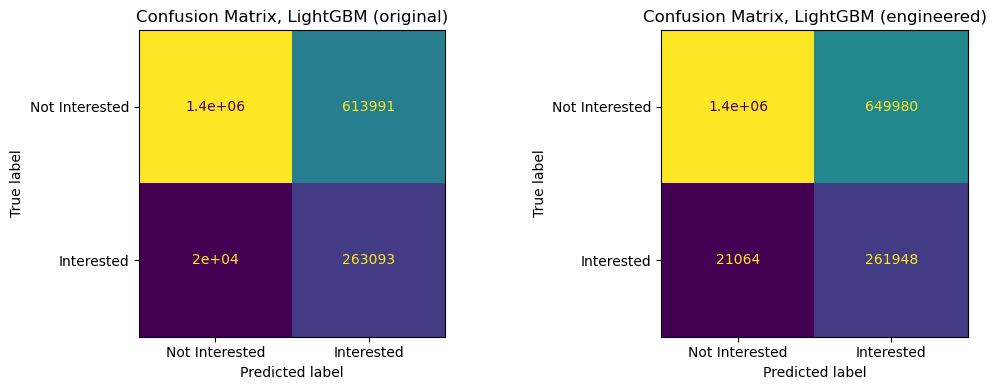

In [7]:
# confusion matrices for LightGBM original vs engineered
cm_orig = confusion_matrix(y_val, lgb_orig_cls)
cm_eng  = confusion_matrix(y_val_e, lgb_eng_cls)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(axes, [cm_orig, cm_eng],
                          ['LightGBM (original)', 'LightGBM (engineered)']):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Interested', 'Interested'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'Confusion Matrix, {title}')
plt.tight_layout()
plt.show()

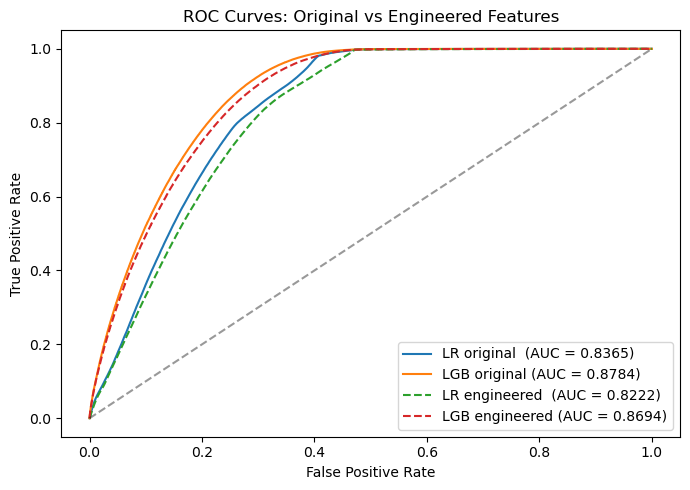

In [8]:
# ROC curves for all four models
fpr_lr_o,  tpr_lr_o,  _ = roc_curve(y_val,   lr_orig_preds)
fpr_lgb_o, tpr_lgb_o, _ = roc_curve(y_val,   lgb_orig_preds)
fpr_lr_e,  tpr_lr_e,  _ = roc_curve(y_val_e, lr_eng_preds)
fpr_lgb_e, tpr_lgb_e, _ = roc_curve(y_val_e, lgb_eng_preds)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr_o,  tpr_lr_o,  label=f'LR original  (AUC = {lr_orig_auc:.4f})')
plt.plot(fpr_lgb_o, tpr_lgb_o, label=f'LGB original (AUC = {lgb_orig_auc:.4f})')
plt.plot(fpr_lr_e,  tpr_lr_e,  linestyle='--', label=f'LR engineered  (AUC = {lr_eng_auc:.4f})')
plt.plot(fpr_lgb_e, tpr_lgb_e, linestyle='--', label=f'LGB engineered (AUC = {lgb_eng_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Original vs Engineered Features')
plt.legend()
plt.tight_layout()
plt.show()

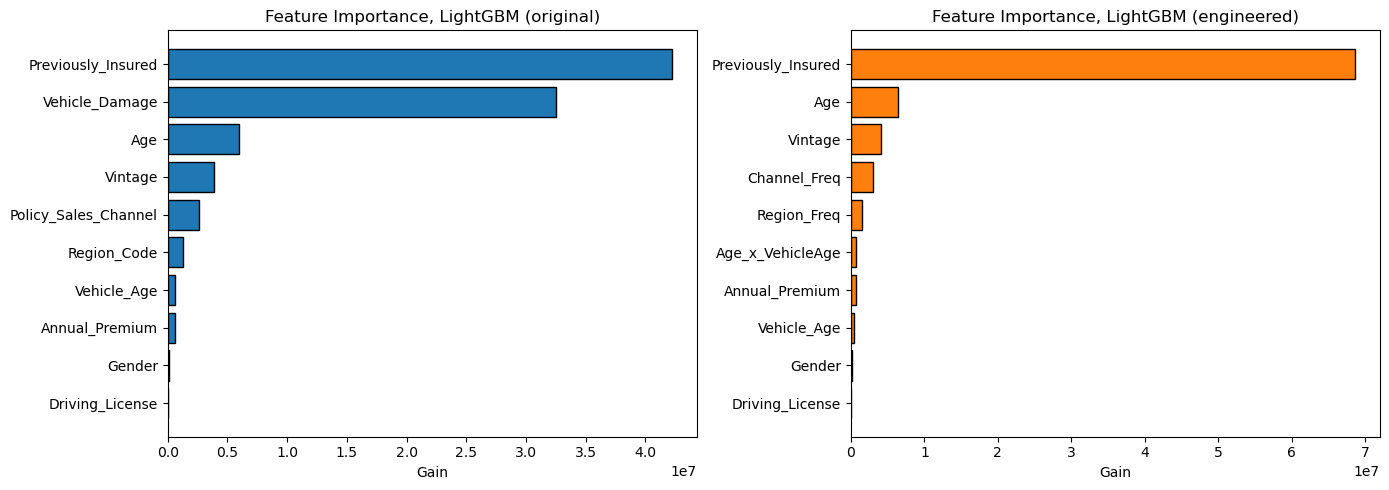

In [9]:
# Feature importance (gain), LightGBM original vs engineered side by side
imp_orig = pd.Series(lgb_orig.feature_importances_, index=original_features).sort_values()
imp_eng  = pd.Series(lgb_eng.feature_importances_,  index=eng_features).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(imp_orig.index, imp_orig.values, edgecolor='black')
axes[0].set_title('Feature Importance, LightGBM (original)')
axes[0].set_xlabel('Gain')

axes[1].barh(imp_eng.index, imp_eng.values, edgecolor='black', color='tab:orange')
axes[1].set_title('Feature Importance, LightGBM (engineered)')
axes[1].set_xlabel('Gain')
plt.tight_layout()
plt.show()

## Step 7: Submission

Best model was LightGBM on original features, so we use that for the final Kaggle submission.

In [10]:
test_preds = lgb_orig.predict_proba(X_test_orig)[:, 1]

submission = pd.DataFrame({
    'id': df_test['id'],
    'Response': test_preds
})

submission.to_csv('data/processed/submission.csv', index=False)
print(f"Submission saved: {len(submission):,} rows")
submission.head()

Submission saved: 7,669,866 rows


,id,Response
0,11504798,0.052352
1,11504799,0.842270
2,11504800,0.694400
3,11504801,0.000689
4,11504802,0.236849


## Step 8: Conclusion

LightGBM clearly outperformed Logistic Regression on this dataset, which makes sense given the non-linear relationships we saw in the EDA. Both models used class weighting to deal with the ~12% positive class imbalance.

The main takeaway from the feature engineering experiment is that it didn't help LightGBM. The AUC actually got slightly worse. I think this is because tree-based models already handle things like high-cardinality categoricals and feature interactions on their own, so the manual transformations (frequency encoding, dropping correlated features, interaction terms) didn't add anything useful. In hindsight it makes sense: if the model can already learn those patterns from the raw data, transforming them just loses information. It was still worth trying though, because for Logistic Regression some of those transformations did help a bit.

Looking at the feature importance plot, `Previously_Insured` dominates by a huge margin, which lines up perfectly with what we saw in the EDA (basically zero response rate from already-insured customers). After that, `Vehicle_Age` and `Annual_Premium` are the next most important, followed by `Policy_Sales_Channel` and `Region_Code`.

Some things that could be improved: I only used a single train/val split, so k-fold cross-validation would give a more reliable estimate. I also didn't tune the decision threshold (just used 0.5), which in a real scenario you'd want to optimize based on the business cost of false positives vs missed sales. Finally, trying other models like CatBoost or XGBoost, or even stacking, could potentially squeeze out a bit more performance.